In [106]:
with open('names.txt', 'r') as file:
    names = file.read().splitlines()

names = [name.lower() for name in names]

In [107]:
chars = sorted(list(set(''.join(names))))

stoi = { ch:i+1 for i,ch in enumerate(chars) }
stoi['$'] = 0
itos = { i:ch for ch,i in stoi.items() }
vocab_size = len(stoi)
vocab_size


30

In [108]:
block_size = 3

In [109]:
import flashlight

def get_dataset(names):
  X = []
  Y = []
  for name in names[:10]:
      context = [0]*block_size
      for ch  in name + '$':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
  X = flashlight.Tensor(X)
  Y = flashlight.Tensor(Y)
  return X,Y

In [110]:
def view_input_output(X, Y):
  for (context, output) in zip(X, Y):
    context_sequence = [itos[x] for x in context]
    out = itos[output]

In [111]:
import random
random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

X_train, Y_train = get_dataset(names[:n1])
X_train._label = "X_train"; Y_train._label = "Y_train"
X_dev, Y_dev = get_dataset(names[n1:n2])
X_dev._label = "X_dev"; Y_dev._label = "Y_dev"
X_test, Y_test = get_dataset(names[n2:])
X_test._label = "X_test"; Y_test._label = "Y_test"

view_input_output(X_test[:2].numpy(), Y_test[:2].numpy())

In [112]:
X_train.shape, Y_train.shape

((90, 3), (90,))

In [113]:
embedding_size = 10
hidden_layers = 200

In [114]:
g = flashlight.Generator().manual_seed(2147483647)

In [84]:
C = flashlight.randn((vocab_size, embedding_size), generator=g); C._label = "C"
W1 = flashlight.randn((embedding_size * block_size, hidden_layers), generator=g); W1._label = "W1"

W2 = flashlight.randn(hidden_layers, vocab_size, generator=g); W2._label = "W2"
B2 = flashlight.randn(vocab_size, generator=g); B2._label = "B2"

bngain = flashlight.ones(1, hidden_layers); bngain._label = "bngain"
bnbias = flashlight.zeros(1, hidden_layers); bnbias._label = "bnbias"

In [115]:
W1.shape

(30, 200)

In [116]:
parameters = [C, W1, W2, B2, bngain, bnbias]
for p in parameters:
  p.requires_grad = True

In [117]:
number_of_parameters = sum(p.nelement() for p in parameters)
number_of_parameters

12730

In [118]:
X_train.shape, C.shape

((90, 3), (30, 10))

In [119]:
def forward_pass(X, Y, bnmean_running, bnstd_running):
  emb = C[X]
  embcat = emb.view(emb.shape[0], -1)
  pass_through_hidden = embcat @ W1
  mean_hidden = pass_through_hidden.mean(0, keepdim=True)
  std_hidden = pass_through_hidden.std(0, keepdim=True)

  with flashlight.no_grad():
    bnmean_running = bnmean_running * 0.999 + mean_hidden * 0.001
    bnstd_running = bnstd_running * 0.999 + std_hidden * 0.001

  normalized = (pass_through_hidden - mean_hidden)/std_hidden
  apply_batch_nomalisation = bngain * normalized + bnbias
  non_linearity = flashlight.tanh(apply_batch_nomalisation)
  logits = non_linearity @ W2 + B2
  output_probs = flashlight.softmax(logits, dim=1)
  indices = flashlight.arange(output_probs.shape[0])
  likelihood = output_probs[indices, Y]
  log_likelihood = flashlight.log(likelihood)
  loss = -log_likelihood.mean()
  return {
    "loss": loss,
    "bnmean_running": bnmean_running,
    "bnstd_running": bnstd_running
  }

In [120]:
def forward_pass_batch(X, Y, bnmean_running, bnstd_running, batch_size=32):
  random_batch_indices = flashlight.randint(0, X_train.shape[0], (batch_size,), generator=g)
  X_batch = X[random_batch_indices]
  Y_batch = Y[random_batch_indices]
  result = forward_pass(X_batch, Y_batch, bnmean_running, bnstd_running)
  return result

In [126]:
def train(X, Y, epochs=50000, log_interval=1000, lr=0.01):
  bnmean_running = flashlight.zeros(1, hidden_layers)
  bnstd_running = flashlight.ones(1, hidden_layers)
  losses = []
  for epoch in range(epochs):
    result = forward_pass_batch(X, Y, bnmean_running, bnstd_running)
    batch_loss = result["loss"]
    bnmean_running = result["bnmean_running"]
    bnstd_running = result["bnstd_running"]
    losses.append((epoch, batch_loss.item()))

    for p in parameters:
      p.grad = None
    result["loss"].backward()

    for p in parameters:
      if p.grad is not None:
        p.data += -lr * p.grad.data
    if epoch % log_interval == 0:
      print(f"Epoch: {epoch}: Loss: {result['loss'].item()}")
  final_loss = losses[epochs - 1]  
  return {
    "losses": losses,
    "final_loss": final_loss[1],
    "bnmean_running": bnmean_running,
    "bnstd_running": bnstd_running
  }

In [127]:
import importlib
importlib.reload(flashlight)

result = train(X_train, Y_train)
losses = result["losses"]
final_loss = result["final_loss"]
bnmean_running = result["bnmean_running"]
bnstd_running = result["bnstd_running"]
print('Final loss', final_loss)

Epoch: 0: Loss: 0.23796825110912323
Epoch: 1000: Loss: 0.4376480281352997
Epoch: 2000: Loss: 0.5508111715316772
Epoch: 3000: Loss: 0.34677523374557495
Epoch: 4000: Loss: 0.23625898361206055
Epoch: 5000: Loss: 0.14559035003185272
Epoch: 6000: Loss: 0.26192718744277954
Epoch: 7000: Loss: 0.3708324432373047
Epoch: 8000: Loss: 0.5828953981399536
Epoch: 9000: Loss: 0.11638067662715912
Epoch: 10000: Loss: 0.10992057621479034
Epoch: 11000: Loss: 0.19788528978824615
Epoch: 12000: Loss: 0.5627570748329163
Epoch: 13000: Loss: 0.304097980260849
Epoch: 14000: Loss: 0.14888489246368408
Epoch: 15000: Loss: 0.23871450126171112
Epoch: 16000: Loss: 0.25515034794807434
Epoch: 17000: Loss: 0.3131895363330841
Epoch: 18000: Loss: 0.27775460481643677
Epoch: 19000: Loss: 0.3299615979194641
Epoch: 20000: Loss: 0.3944464921951294
Epoch: 21000: Loss: 0.40731438994407654
Epoch: 22000: Loss: 0.19039514660835266
Epoch: 23000: Loss: 0.7396413087844849
Epoch: 24000: Loss: 0.5226578116416931
Epoch: 25000: Loss: 0.228

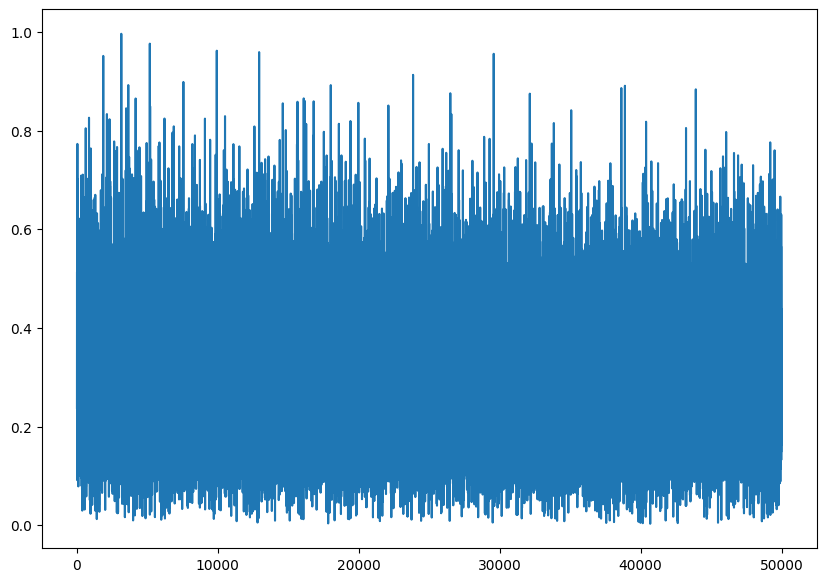

In [128]:
# Plot loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.plot([x for x, _ in losses], [y for _, y in losses])
plt.show()

In [129]:
def validate(X, Y, bnmean_running, bnstd_running):
  emb = C[X]; emb._label = "embeddings"
  embcat = emb.view(emb.shape[0], -1); embcat._label = "embedding_cat"
  pass_through_hidden = embcat @ W1; pass_through_hidden._label = "pass_through_hidden"
  mean_hidden = pass_through_hidden.mean(0, keepdim=True); mean_hidden._label = "mean_hidden"
  std_hidden = pass_through_hidden.std(0, keepdim=True); std_hidden._label = "std_hidden"
  normalized_numerator = pass_through_hidden - mean_hidden; normalized_numerator._label = "normalized_numerator"
  normalized_denominator = std_hidden; normalized_denominator._label = "normalized_denominator"
  batch_normalisation = bngain * (normalized_numerator/normalized_denominator) + bnbias; batch_normalisation._label = "batch_normalisation"
  non_linearity = flashlight.tanh(batch_normalisation); non_linearity._label = "non_linearity"
  logits = non_linearity @ W2 + B2; logits._label = "logits"
  output_probs = flashlight.softmax(logits, dim=1); output_probs._label = "output_probs"
  indices = flashlight.arange(output_probs.shape[0]); indices._label = "indices"
  likelihood = output_probs[indices, Y]; likelihood._label = "likelihood"
  log_likelihood = flashlight.log(likelihood); log_likelihood._label = "log_likelihood"
  loss = -log_likelihood.mean(); loss._label = "loss"
  return loss

In [130]:
test_loss = validate(X_test, Y_test, bnmean_running, bnstd_running)
print('Test loss', test_loss)

Test loss Flashlight Tensor(shape=(), requires_grad=True)


Validation loss Flashlight Tensor(shape=(), requires_grad=True)


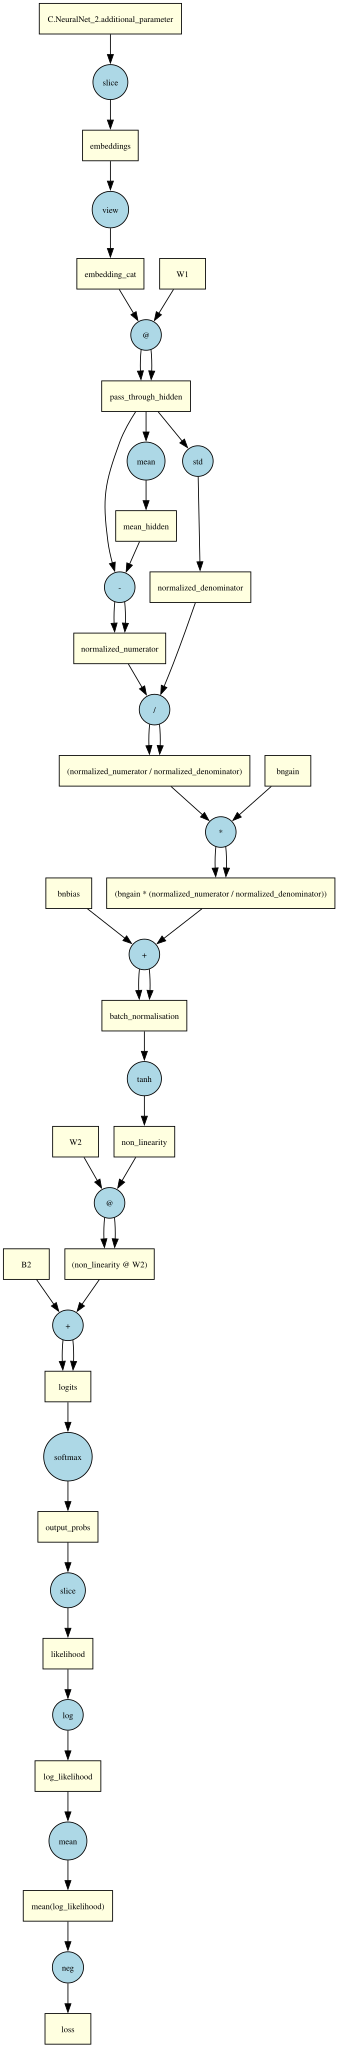

In [131]:
from flashlight import draw_dot
validation_loss = validate(X_dev, Y_dev, bnmean_running, bnstd_running)
print('Validation loss', validation_loss)
draw_dot(validation_loss, use_graphviz=True)

In [132]:
# Generate 200 names using the trained model above

names = []
for _ in range(200):
    out = []
    context = [0] * block_size
    while True:
        emb = C[flashlight.Tensor([context])]
        embcat = emb.view(1, -1)
        pass_through_hidden = embcat @ W1
        normalized = (pass_through_hidden - bnmean_running) / bnstd_running
        apply_batch_norm = bngain * normalized + bnbias
        h = flashlight.tanh(apply_batch_norm)
        logits = h @ W2 + B2
        probs = flashlight.softmax(logits, dim=1)
        ix = flashlight.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break
        out.append(itos[ix])
        context = context[1:] + [ix]
    names.append(''.join(out))

for name in names:
    print(name)



sunder
sunder
sunder
kaveen
aadal azhagi
sayen
aaharshya
sayen
aadal azhagi
vandyaaranya
aadal azhagi
aahhiieen
hemaloshinee
rakhi
aadal azhagi
kaveen
sunder
dhusyant
dhusyant
kaveen
aadal azhagi
aaharshya
aaharshya
dhusyant
kaveen
vidya
kaveen
aaharshya
kaveen
vandyaaranya
rakhi
rakhi
sayen
sunder
aaharshya
dhusyant
rakhi
dhusyant
dhusyant
sayen
sayen
vidyaaranya
aaharskya
dhusyant
vidyaaranya
hemaloshinee
kaveen
vidya
dhusyant
hemaloshinee
sunder
kaveen
dhusyant
kaveen
kaveen
sunder
vandya
sayen
vidya
sayen
kaveen
vidyaaranya
vandya
kaveen
aaharshya
vidya
vidya
rakhi
aaharshya
aaharshya
aaharshya
aadal azhagi
sunder
dhusyant
kaveen
aadal azhagi
hemaloshinee
aaharshya
vidyaaranya
dhusyant
dhusyant
vidya
vandyaaranya
rakhi
rakhi
aadal azhagi
hemaloshinee
rakhi
rakhi
dhusyant
aadal azhagi
sayen
aaharshya
aaharshya
sayen
sayen
hemaloshinee
dhusyant
kaveen
dhusyant
vandyaaranya
hemaloshinee
hemaloshinee
hemaloshinee
vidya
hemaloshinee
kaveen
aadal azhagi
hemaloshinee
aaharshya
aaharshya
s

### Using classes from Neural package

In [133]:
import flashlight

In [134]:
C = flashlight.randn((vocab_size, embedding_size), generator=g, requires_grad=True); C._label = "C"

In [135]:
from flashlight.neural import Linear, BatchNorm1d, Tanh, NeuralNet


linear1 = Linear(embedding_size * block_size, hidden_layers, generator=g)
batchnorm1 = BatchNorm1d(hidden_layers, training=True)
tanh1 = Tanh()
linear2 = Linear(hidden_layers, vocab_size, generator=g)

def calculate_output(x):
  return flashlight.softmax(x)


def calculate_loss(x, y):
  return flashlight.nll_loss(x, y)

model = NeuralNet(
  calculate_output=calculate_output,
  calculate_loss=calculate_loss,
)
model.add_layer(linear1)
model.add_layer(batchnorm1)
model.add_layer(tanh1)
model.add_layer(linear2)

model.add_additional_parameter_to_the_training(C)

model, linear1, batchnorm1, tanh1

(NeuralNet_3(layers=[
     Linear_5(in_features=30, out_features=200),
     BatchNorm1d_3(num_features=200, momentum=0.001, training=True),
     Tanh_3,
     Linear_6(in_features=200, out_features=30)
 ]),
 Linear_5(in_features=30, out_features=200),
 BatchNorm1d_3(num_features=200, momentum=0.001, training=True),
 Tanh_3)

In [136]:
model.parameters()

[Flashlight Tensor(shape=(30, 200), requires_grad=True),
 Flashlight Tensor(shape=(200,), requires_grad=True),
 Flashlight Tensor(shape=(200,), requires_grad=True),
 Flashlight Tensor(shape=(200,), requires_grad=True),
 Flashlight Tensor(shape=(200, 30), requires_grad=True),
 Flashlight Tensor(shape=(30,), requires_grad=True),
 Flashlight Tensor(shape=(30, 10), requires_grad=True)]

In [102]:
losses = []
for i in range(50000):
  emb = C[X_train]
  embcat = emb.view(emb.shape[0], -1)

  loss = model.train(
    embcat,
    Y_train,
    lr=0.01,
    log_interval=1000,
    batching=True,
    batch_size=32
  )
  if i % 1000 == 0:
    print(f"Epoch: {i}: Loss: {loss.item()}")
  losses.append(loss.item())

Epoch: 0: Loss: 3.961860418319702
Epoch: 1000: Loss: 0.6605192422866821
Epoch: 2000: Loss: 0.48610246181488037
Epoch: 3000: Loss: 0.30784788727760315
Epoch: 4000: Loss: 0.4314243197441101
Epoch: 5000: Loss: 0.327605664730072
Epoch: 6000: Loss: 0.18976569175720215
Epoch: 7000: Loss: 0.4951532483100891
Epoch: 8000: Loss: 0.4694223999977112
Epoch: 9000: Loss: 0.3257507085800171
Epoch: 10000: Loss: 0.44896772503852844
Epoch: 11000: Loss: 0.4207468032836914
Epoch: 12000: Loss: 0.4150330126285553
Epoch: 13000: Loss: 0.2815003991127014
Epoch: 14000: Loss: 0.24003008008003235
Epoch: 15000: Loss: 0.18880920112133026
Epoch: 16000: Loss: 0.4460204541683197
Epoch: 17000: Loss: 0.23298458755016327
Epoch: 18000: Loss: 0.6444091796875
Epoch: 19000: Loss: 0.3365996479988098
Epoch: 20000: Loss: 0.23173007369041443
Epoch: 21000: Loss: 0.29706257581710815
Epoch: 22000: Loss: 0.24366475641727448
Epoch: 23000: Loss: 0.13736672699451447
Epoch: 24000: Loss: 0.4372240900993347
Epoch: 25000: Loss: 0.2388487607

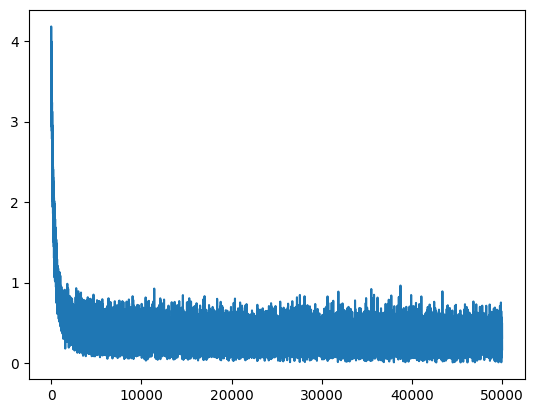

In [103]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.show()

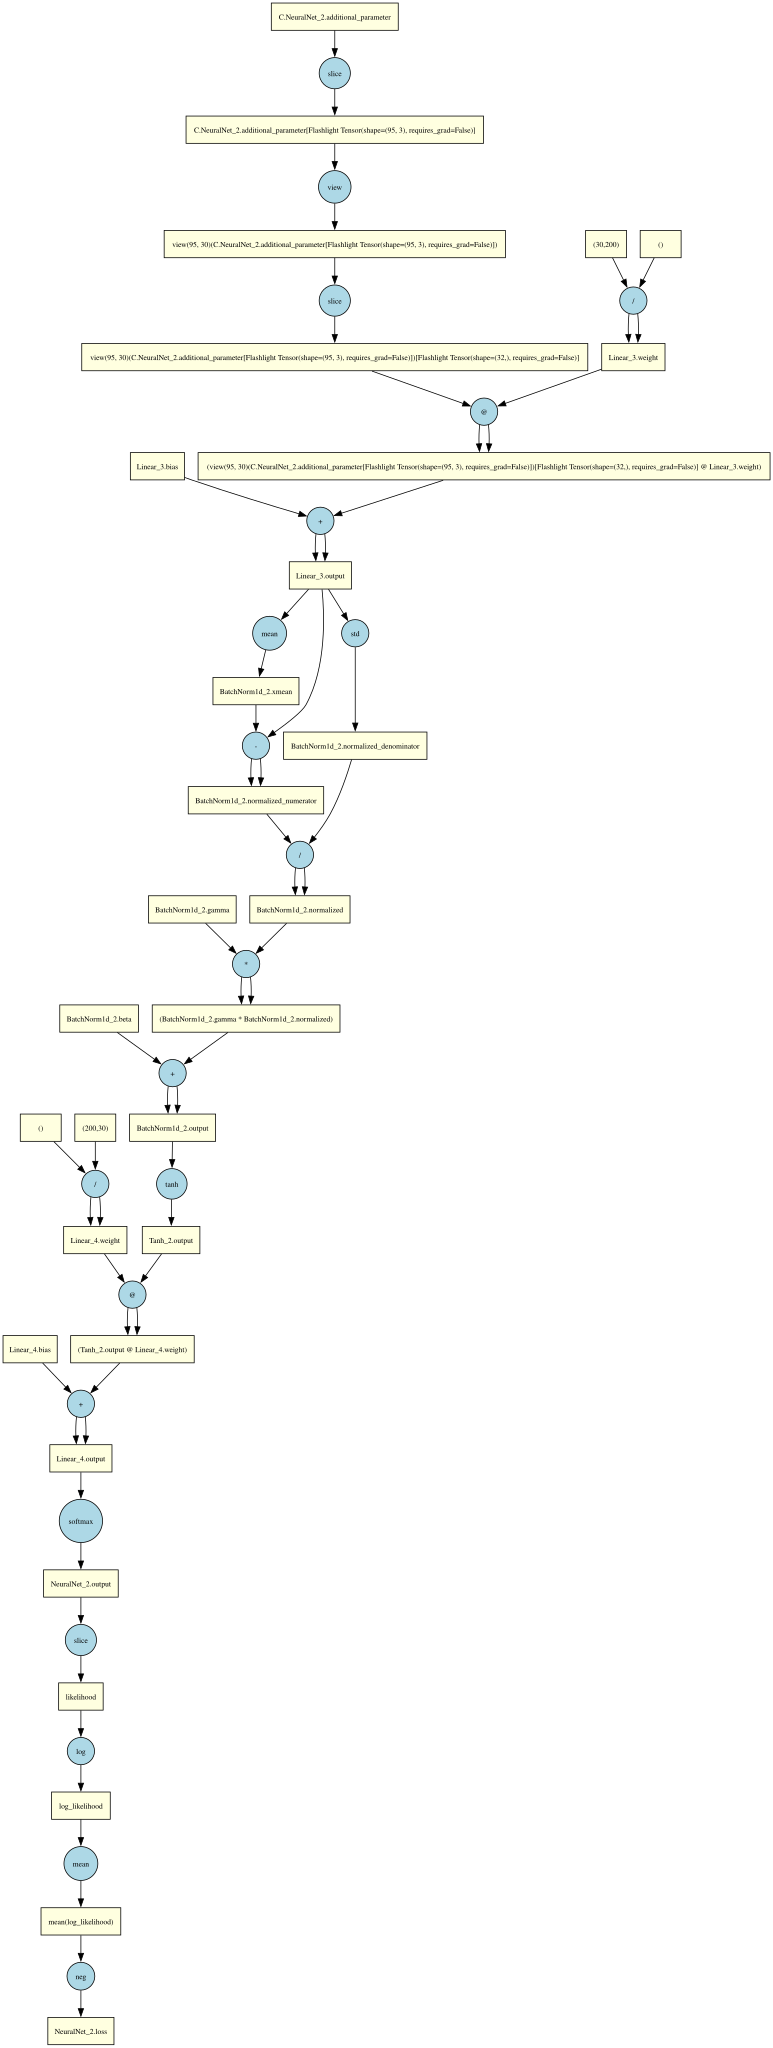

In [104]:
from flashlight import draw_dot

draw_dot(loss, use_graphviz=True)

In [ ]:
nums_generate = 200
names = []
model.set_training(False)
for i in range(nums_generate):
  out = []
  context = [0]*block_size
  while True:
    emb = C[flashlight.Tensor([context])]
    embcat = emb.view(1, -1)
    output = model(embcat)
    ix = flashlight.multinomial(output, num_samples=1, generator=g).item()
    if ix == 0:
      break
    out.append(itos[ix])
    context = context[1:] + [ix]
  names.append(''.join(out))
for name in names:
  print(name)

paurush
paurush
dadhichi
lovyam
aghat
kalaipaavai
ilambiranmohan
vahesan
dushyanthan
dadhichi
paurush
kalaipaavai
jeyaravai
dadhichi
dadhichi
vahesan
i
vahesan
vahesan
dadhichi
paurushyanthan
kalaipaavai
aghat
lovyam
dush
vahesan
vahesan
dush
jeyaravaman
ilambiranmohan
aghat
jeyaravaman
dush
aghat
aghat
lovyam
lovyam
dadhichi
vahesan
dush
vahesan
dadhichi
dush
lovyamsi
kalaipaavaman
dadhichi
kirai
kalaipaavai
aghat
dush
dadhichi
ilambiranmohan
aghat
dushyanthan
kalaipaavai
lovyam
dushyanthan
dushyanthan
lovyam
kalaipaavai
vahesan
dadhichi
dush
dadhichi
kirai
duphan
dadhichi
vahesan
jeyaravai
kiranmohan
paurushyanthan
kiranmohan
lovyam
dadhichi
kirai
jeyaravaman
lovyam
aghat
aghat
jeyaravai
dush
dadhichi
paurushyanthan
paurushyanthan
jeyaravai
lovyam
jeyaravaman
dush
vahesan
kalaipaavai
kiranmohan
jeyaravaman
paurush
jeyaravaman
dadhichi
dush
dush
lovyam
jeyaravaman
dush
aghat
aghat
jeyaravai
paurushyanthan
koravaman
ilambiranmohan
paurush
vahesan
dushyanthan
dush
kirai
kiranmohan
ilamb